# Day 19 - Customer Order Integrated Analysis

지금까지 학습한 JOIN, 집계, CASE WHEN, Subquery와 Window Function을 결합해 고객별 주문 활동을 종합 분석한다.

## 분석 목적

고객별 주문 횟수, 주문 상태, 주문 기간과 평균 주문 간격을 하나의 고객 단위 데이터로 정리한다.

이 결과를 이용해 고객 활동 수준과 관리 대상을 분류한다.

## 분석 질문

1. 고객별 전체 주문 수는 몇 건인가?
2. 완료 주문과 취소 주문은 각각 몇 건인가?
3. 고객별 최초 주문일과 최근 주문일은 언제인가?
4. 고객의 평균 주문 간격은 며칠인가?
5. 전체 고객 평균보다 주문이 많은 고객은 누구인가?
6. 주문 수를 기준으로 고객 순위는 어떻게 되는가?
7. 어떤 고객을 활성화, 유지 또는 주문 문제 점검 대상으로 볼 수 있는가?

In [2]:
# 라이브러리 불러오기
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 프로젝트 경로 설정
project_root = Path.cwd().parent
study_root = project_root.parent.parent

db_path = study_root / "SQL" / "database" / "retail_lab.db"
output_dir = project_root / "outputs"

output_dir.mkdir(parents=True, exist_ok=True)

print("프로젝트 경로:", project_root)
print("데이터베이스 경로:", db_path)
print("출력 경로:", output_dir)

프로젝트 경로: d:\Study\Projects\00_foundation_review
데이터베이스 경로: d:\Study\SQL\database\retail_lab.db
출력 경로: d:\Study\Projects\00_foundation_review\outputs


In [4]:
# DB 존재 여부 확인
print("DB 존재 여부:", db_path.exists())

DB 존재 여부: True


In [5]:
# 데이터베이스 연결
conn = sqlite3.connect(db_path)

print("데이터베이스 연결 완료")

데이터베이스 연결 완료


In [6]:
# 주문 상태 확인
status_query = """
SELECT DISTINCT
    status
FROM orders
ORDER BY status
"""

status_df = pd.read_sql(status_query, conn)

print(status_df)

      status
0  cancelled
1       paid


In [7]:
# 종합 분석 SQL 작성
query = """
SELECT
    customer_comparison.customer_id,
    customer_comparison.customer_name,
    customer_comparison.region,
    customer_comparison.grade,
    customer_comparison.total_order_count,
    customer_comparison.completed_order_count,
    customer_comparison.cancelled_order_count,

    CASE
        WHEN customer_comparison.total_order_count = 0 THEN 0
        ELSE ROUND(
            customer_comparison.completed_order_count
            * 100.0
            / customer_comparison.total_order_count,
            1
        )
    END AS completion_rate,

    customer_comparison.first_order_date,
    customer_comparison.last_order_date,
    customer_comparison.active_period_days,
    customer_comparison.avg_days_between_orders,
    customer_comparison.avg_customer_order_count,
    customer_comparison.order_count_rank,

    CASE
        WHEN customer_comparison.total_order_count = 0
            THEN 'no_order'
        WHEN customer_comparison.total_order_count
             > customer_comparison.avg_customer_order_count
            THEN 'high_activity'
        WHEN customer_comparison.total_order_count >= 2
            THEN 'repeat_customer'
        ELSE 'single_order'
    END AS activity_segment,

    CASE
        WHEN customer_comparison.total_order_count = 0
            THEN 'no_order'
        WHEN customer_comparison.completed_order_count
             = customer_comparison.total_order_count
            THEN 'completed_only'
        WHEN customer_comparison.cancelled_order_count
             = customer_comparison.total_order_count
            THEN 'cancelled_only'
        ELSE 'mixed_status'
    END AS status_segment,

    CASE
        WHEN customer_comparison.total_order_count = 0
            THEN 'activation_candidate'
        WHEN customer_comparison.cancelled_order_count
             > customer_comparison.completed_order_count
            THEN 'order_issue_review'
        WHEN customer_comparison.total_order_count
             > customer_comparison.avg_customer_order_count
            THEN 'retention_priority'
        ELSE 'general_management'
    END AS management_action

FROM (
    SELECT
        customer_summary.customer_id,
        customer_summary.customer_name,
        customer_summary.region,
        customer_summary.grade,
        customer_summary.total_order_count,
        customer_summary.completed_order_count,
        customer_summary.cancelled_order_count,
        customer_summary.first_order_date,
        customer_summary.last_order_date,
        customer_summary.active_period_days,
        customer_summary.avg_days_between_orders,

        ROUND(
            AVG(
                customer_summary.total_order_count * 1.0
            ) OVER (),
            2
        ) AS avg_customer_order_count,

        DENSE_RANK() OVER (
            ORDER BY customer_summary.total_order_count DESC
        ) AS order_count_rank

    FROM (
        SELECT
            order_flow.customer_id,
            order_flow.customer_name,
            order_flow.region,
            order_flow.grade,

            COUNT(order_flow.order_id)
                AS total_order_count,

            SUM(
                CASE
                    WHEN order_flow.status = 'completed'
                        THEN 1
                    ELSE 0
                END
            ) AS completed_order_count,

            SUM(
                CASE
                    WHEN order_flow.status = 'cancelled'
                        THEN 1
                    ELSE 0
                END
            ) AS cancelled_order_count,

            MIN(order_flow.order_date)
                AS first_order_date,

            MAX(order_flow.order_date)
                AS last_order_date,

            CASE
                WHEN COUNT(order_flow.order_id) >= 2 THEN
                    CAST(
                        julianday(MAX(order_flow.order_date))
                        - julianday(MIN(order_flow.order_date))
                        AS INTEGER
                    )
                ELSE NULL
            END AS active_period_days,

            ROUND(
                AVG(
                    CASE
                        WHEN order_flow.previous_order_date
                             IS NOT NULL
                        THEN
                            julianday(order_flow.order_date)
                            - julianday(
                                order_flow.previous_order_date
                            )
                        ELSE NULL
                    END
                ),
                1
            ) AS avg_days_between_orders

        FROM (
            SELECT
                c.customer_id,
                c.customer_name,
                c.region,
                c.grade,
                o.order_id,
                o.order_date,
                o.status,

                LAG(o.order_date) OVER (
                    PARTITION BY c.customer_id
                    ORDER BY o.order_date, o.order_id
                ) AS previous_order_date

            FROM customers AS c
            LEFT JOIN orders AS o
                ON c.customer_id = o.customer_id
        ) AS order_flow

        GROUP BY
            order_flow.customer_id,
            order_flow.customer_name,
            order_flow.region,
            order_flow.grade
    ) AS customer_summary
) AS customer_comparison

ORDER BY
    customer_comparison.order_count_rank,
    customer_comparison.customer_id
"""

In [8]:
# SQL 실행
df = pd.read_sql(query, conn)

print(df.head())

   customer_id customer_name   region  grade  total_order_count  \
0            1           Kim    Seoul    VIP                  2   
1            2           Lee    Busan  BASIC                  1   
2            3          Park    Seoul   GOLD                  1   
3            4          Choi  Incheon  BASIC                  0   

   completed_order_count  cancelled_order_count  completion_rate  \
0                      0                      0              0.0   
1                      0                      0              0.0   
2                      0                      1              0.0   
3                      0                      0              0.0   

  first_order_date last_order_date  active_period_days  \
0       2026-07-20      2026-07-22                 2.0   
1       2026-07-21      2026-07-21                 NaN   
2       2026-07-23      2026-07-23                 NaN   
3              NaN             NaN                 NaN   

   avg_days_between_orders  avg_

In [9]:
# DataFrame 크기 확인
print("행과 열 개수:", df.shape)

행과 열 개수: (4, 17)


In [10]:
# 자료형 확인
print(df.dtypes)

customer_id                   int64
customer_name                   str
region                          str
grade                           str
total_order_count             int64
completed_order_count         int64
cancelled_order_count         int64
completion_rate             float64
first_order_date                str
last_order_date                 str
active_period_days          float64
avg_days_between_orders     float64
avg_customer_order_count    float64
order_count_rank              int64
activity_segment                str
status_segment                  str
management_action               str
dtype: object


In [11]:
# 결측치 확인
print(df.isna().sum())

customer_id                 0
customer_name               0
region                      0
grade                       0
total_order_count           0
completed_order_count       0
cancelled_order_count       0
completion_rate             0
first_order_date            1
last_order_date             1
active_period_days          3
avg_days_between_orders     3
avg_customer_order_count    0
order_count_rank            0
activity_segment            0
status_segment              0
management_action           0
dtype: int64


In [12]:
# 날짜 자료형 변환
df["first_order_date"] = pd.to_datetime(
    df["first_order_date"]
)

df["last_order_date"] = pd.to_datetime(
    df["last_order_date"]
)

print(df.dtypes)

customer_id                          int64
customer_name                          str
region                                 str
grade                                  str
total_order_count                    int64
completed_order_count                int64
cancelled_order_count                int64
completion_rate                    float64
first_order_date            datetime64[us]
last_order_date             datetime64[us]
active_period_days                 float64
avg_days_between_orders            float64
avg_customer_order_count           float64
order_count_rank                     int64
activity_segment                       str
status_segment                         str
management_action                      str
dtype: object


In [13]:
# 고객 ID 중복 확인
duplicate_customer_count = (
    df["customer_id"].duplicated().sum()
)

print(
    "중복 고객 ID 수:",
    duplicate_customer_count
)

중복 고객 ID 수: 0


In [14]:
# 고객 활동 분류 확인
activity_count = (
    df["activity_segment"].value_counts()
)

print(activity_count)

activity_segment
single_order     2
high_activity    1
no_order         1
Name: count, dtype: int64


In [15]:
# 관리 대상 분류 확인
management_count = (
    df["management_action"].value_counts()
)

print(management_count)

management_action
retention_priority      1
general_management      1
order_issue_review      1
activation_candidate    1
Name: count, dtype: int64


In [16]:
# 유지 우선 고객 확인
retention_customers = df[
    df["management_action"]
    == "retention_priority"
]

print(retention_customers)

   customer_id customer_name region grade  total_order_count  \
0            1           Kim  Seoul   VIP                  2   

   completed_order_count  cancelled_order_count  completion_rate  \
0                      0                      0              0.0   

  first_order_date last_order_date  active_period_days  \
0       2026-07-20      2026-07-22                 2.0   

   avg_days_between_orders  avg_customer_order_count  order_count_rank  \
0                      2.0                       1.0                 1   

  activity_segment status_segment   management_action  
0    high_activity   mixed_status  retention_priority  


In [17]:
# 활성화 후보 확인
activation_customers = df[
    df["management_action"]
    == "activation_candidate"
]

print(activation_customers)

   customer_id customer_name   region  grade  total_order_count  \
3            4          Choi  Incheon  BASIC                  0   

   completed_order_count  cancelled_order_count  completion_rate  \
3                      0                      0              0.0   

  first_order_date last_order_date  active_period_days  \
3              NaT             NaT                 NaN   

   avg_days_between_orders  avg_customer_order_count  order_count_rank  \
3                      NaN                       1.0                 3   

  activity_segment status_segment     management_action  
3         no_order       no_order  activation_candidate  


In [18]:
# 주문 문제 점검 후보 확인
issue_customers = df[
    df["management_action"]
    == "order_issue_review"
]

print(issue_customers)

   customer_id customer_name region grade  total_order_count  \
2            3          Park  Seoul  GOLD                  1   

   completed_order_count  cancelled_order_count  completion_rate  \
2                      0                      1              0.0   

  first_order_date last_order_date  active_period_days  \
2       2026-07-23      2026-07-23                 NaN   

   avg_days_between_orders  avg_customer_order_count  order_count_rank  \
2                      NaN                       1.0                 2   

  activity_segment  status_segment   management_action  
2     single_order  cancelled_only  order_issue_review  


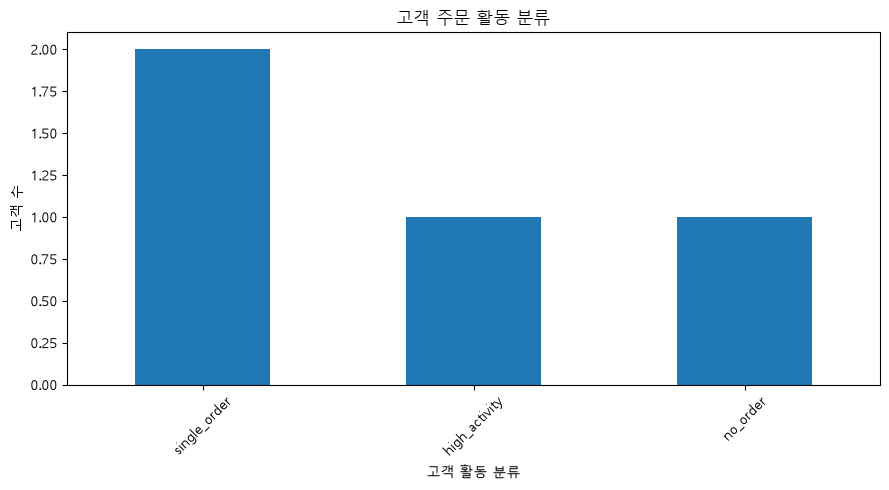

그래프 저장 경로: d:\Study\Projects\00_foundation_review\outputs\customer_activity_segment.png


In [23]:
# 고객 활동 분류 그래프
activity_count.plot.bar(
    figsize=(9, 5)
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.title("고객 주문 활동 분류")
plt.xlabel("고객 활동 분류")
plt.ylabel("고객 수")
plt.xticks(rotation=45)
plt.tight_layout()

figure_path = (
    output_dir
    / "customer_activity_segment.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("그래프 저장 경로:", figure_path)

In [24]:
# CSV 저장
output_path = (
    output_dir
    / "customer_order_integrated_analysis.csv"
)

df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d"
)

print("CSV 저장 경로:", output_path)

CSV 저장 경로: d:\Study\Projects\00_foundation_review\outputs\customer_order_integrated_analysis.csv


In [25]:
# 저장 결과 확인
saved_df = pd.read_csv(output_path)

print(saved_df.head())
print("저장된 데이터 크기:", saved_df.shape)
print("CSV 존재 여부:", output_path.exists())
print("PNG 존재 여부:", figure_path.exists())

   customer_id customer_name   region  grade  total_order_count  \
0            1           Kim    Seoul    VIP                  2   
1            2           Lee    Busan  BASIC                  1   
2            3          Park    Seoul   GOLD                  1   
3            4          Choi  Incheon  BASIC                  0   

   completed_order_count  cancelled_order_count  completion_rate  \
0                      0                      0              0.0   
1                      0                      0              0.0   
2                      0                      1              0.0   
3                      0                      0              0.0   

  first_order_date last_order_date  active_period_days  \
0       2026-07-20      2026-07-22                 2.0   
1       2026-07-21      2026-07-21                 NaN   
2       2026-07-23      2026-07-23                 NaN   
3              NaN             NaN                 NaN   

   avg_days_between_orders  avg_

In [26]:
# 데이터베이스 연결 종료
conn.close()

print("데이터베이스 연결 종료")

데이터베이스 연결 종료


## 결과 해석

- 전체 고객은 4명이며, 고객별 주문 활동을 고객 1명당 1행으로 정리했다.
- 전체 고객의 평균 주문 수는 약 1건으로 확인됐다.
- 평균보다 주문 수가 많은 high_activity 고객은 1명이다.
- 주문 이력이 없는 고객은 activation_candidate로 분류했다.
- 취소 주문 수가 완료 주문 수보다 많은 고객은 order_issue_review 대상으로 분류했다.
- 평균보다 주문 활동이 높은 고객은 retention_priority로 분류했다.
- 평균 주문 간격은 고객별 재주문 주기를 비교하는 보조 지표로 사용할 수 있다.
- 주문 횟수 순위가 높다고 해서 매출 기여도나 수익성이 높다는 뜻은 아니다.

## 분석 한계

1. 현재 orders 테이블에는 상품 ID, 수량과 매출액이 없다.
2. 주문 횟수와 상태는 분석할 수 있지만 고객별 매출 기여도는 판단할 수 없다.
3. 관리 대상 분류는 학습을 위해 만든 규칙이며 실제 업무 정책이 아니다.
4. 취소 사유가 없으므로 취소 주문이 많은 원인을 확인할 수 없다.
5. 평균 주문 간격은 주문이 2건 이상인 고객만 계산할 수 있다.
6. 주문 상태가 completed와 cancelled 외에 존재한다면 상태 분류 기준을 추가해야 한다.
7. 데이터의 마지막 날짜 이후 고객 행동은 관측할 수 없다.
8. 주문이 없는 고객이 실제 미구매 고객인지 데이터 누락 고객인지는 확인할 수 없다.